# Tutorial 8 · Gradient Descent & Conditioning — Part B

**~40 minutes · after the worksheet**

Run gradient descent on quadratic bowls and isolate the roles of learning rate, condition number, scaling, and momentum.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Learning-rate regimes


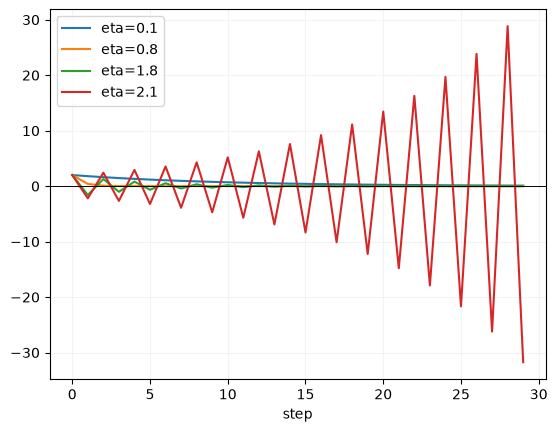

In [1]:
#| fig-alt: 'One-dimensional gradient-descent trajectories for four learning rates, illustrating slow convergence, oscillation, and divergence.'
import numpy as np
import matplotlib.pyplot as plt

def run(eta, steps=30):
    x = 2.0; history=[]
    for _ in range(steps): history.append(x); x -= eta*x
    return history
for eta in [.1, .8, 1.8, 2.1]: plt.plot(run(eta), label=f"eta={eta}")
plt.axhline(0, color="black", lw=.7); plt.legend(); plt.xlabel("step"); plt.grid(alpha=.15);


## 2 · Conditioning creates a zig-zag


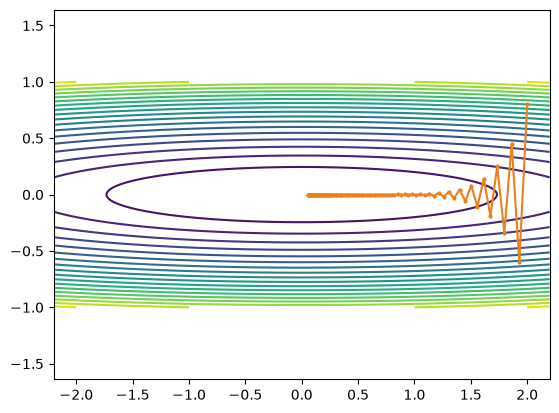

In [2]:
#| fig-alt: 'Contour plot of an ill-conditioned quadratic with a gradient-descent path zigzagging down the narrow valley.'
H = np.diag([1., 50.])
x = np.array([2., .8]); path=[x.copy()]
for _ in range(100):
    x -= .035*(H @ x); path.append(x.copy())
path=np.array(path)
xx, yy=np.meshgrid(np.linspace(-2.2,2.2,160), np.linspace(-1,1,160))
plt.contour(xx,yy,.5*(xx**2+50*yy**2),levels=18)
plt.plot(path[:,0],path[:,1],"o-",ms=2,color="#EB811B"); plt.axis("equal");


## 3 · Momentum on the same bowl


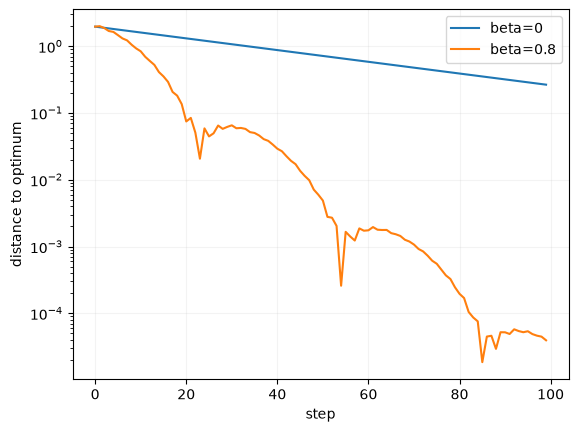

In [3]:
#| fig-alt: 'Two trajectories on an ill-conditioned quadratic comparing plain gradient descent with momentum.'
def optimize(momentum):
    x=np.array([2.,.8]); v=np.zeros(2); path=[]
    for _ in range(100):
        v=momentum*v + H@x; x=x-.02*v; path.append(x.copy())
    return np.array(path)
for beta in [0, .8]:
    p=optimize(beta); plt.semilogy(np.linalg.norm(p,axis=1),label=f"beta={beta}")
plt.legend(); plt.xlabel("step"); plt.ylabel("distance to optimum"); plt.grid(alpha=.15);


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
